In [62]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [64]:
# Load datasets
all_stream_info = pd.read_csv('all_stream_info.csv')
points_transaction_log = pd.read_csv('points_transaction_log.csv')

In [66]:
# Display dataset information
print("All Stream Info Dataset Info:")
print(all_stream_info.info())
print("\nPoints Transaction Log Dataset Info:")
print(points_transaction_log.info())


All Stream Info Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3148 entries, 0 to 3147
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   liveStreamID             3148 non-null   int64  
 1   beginTime                3148 non-null   object 
 2   endTime                  3148 non-null   object 
 3   duration                 3148 non-null   int64  
 4   closeBy                  3051 non-null   object 
 5   maxLiveViewerCount       3148 non-null   int64  
 6   maxLiveViewerTime        1838 non-null   object 
 7   privateLiveStream        3148 non-null   int64  
 8   receivedLikeCount        3148 non-null   int64  
 9   streamerType             3148 non-null   int64  
 10  isShow                   3148 non-null   bool   
 11  cultureGroup             0 non-null      float64
 12  userID                   3148 non-null   object 
 13  registerTime             3148 non-null   object 

In [68]:
# Check for missing values
print("\nMissing Values in All Stream Info:")
print(all_stream_info.isnull().sum())
print("\nMissing Values in Points Transaction Log:")
print(points_transaction_log.isnull().sum())


Missing Values in All Stream Info:
liveStreamID                  0
beginTime                     0
endTime                       0
duration                      0
closeBy                      97
maxLiveViewerCount            0
maxLiveViewerTime          1310
privateLiveStream             0
receivedLikeCount             0
streamerType                  0
isShow                        0
cultureGroup               3148
userID                        0
registerTime                  0
registerCountry               0
isContracted               3148
uniqueViewerCount             0
ios                           0
android                       0
durationGTE5sec               0
durationGTE2min               0
durationGTE10min              0
totalViewerDuration        1459
avgViewerDuration          1459
avgStreamJoinDuration      1459
count                         0
followIncreaseEstimated       0
receivePointEstimated         0
dau                        3148
dtype: int64

Missing Values in Poin

In [70]:
# Drop rows with missing values
all_stream_info.dropna(inplace=True)
points_transaction_log.dropna(inplace=True)


In [72]:
# Verify data cleaning
print("\nData Cleaned - Remaining Null Values:")
print(all_stream_info.isnull().sum())


Data Cleaned - Remaining Null Values:
liveStreamID               0
beginTime                  0
endTime                    0
duration                   0
closeBy                    0
maxLiveViewerCount         0
maxLiveViewerTime          0
privateLiveStream          0
receivedLikeCount          0
streamerType               0
isShow                     0
cultureGroup               0
userID                     0
registerTime               0
registerCountry            0
isContracted               0
uniqueViewerCount          0
ios                        0
android                    0
durationGTE5sec            0
durationGTE2min            0
durationGTE10min           0
totalViewerDuration        0
avgViewerDuration          0
avgStreamJoinDuration      0
count                      0
followIncreaseEstimated    0
receivePointEstimated      0
dau                        0
dtype: int64


In [74]:
# Display column names for both datasets
print("Columns in all_stream_info:", all_stream_info.columns)
print("Columns in points_transaction_log:", points_transaction_log.columns)


Columns in all_stream_info: Index(['liveStreamID', 'beginTime', 'endTime', 'duration', 'closeBy',
       'maxLiveViewerCount', 'maxLiveViewerTime', 'privateLiveStream',
       'receivedLikeCount', 'streamerType', 'isShow', 'cultureGroup', 'userID',
       'registerTime', 'registerCountry', 'isContracted', 'uniqueViewerCount',
       'ios', 'android', 'durationGTE5sec', 'durationGTE2min',
       'durationGTE10min', 'totalViewerDuration', 'avgViewerDuration',
       'avgStreamJoinDuration', 'count', 'followIncreaseEstimated',
       'receivePointEstimated', 'dau'],
      dtype='object')
Columns in points_transaction_log: Index(['receiverUserID', 'utcTimestamp', 'id', 'userID', 'type', 'giftID',
       'point', 'timestamp', 'isCanceled', 'migration', 'recordID',
       'recordPoint', 'tradeID'],
      dtype='object')


In [76]:
# Merge datasets based on userID
merged_data = pd.merge(all_stream_info, points_transaction_log, on='userID', how='inner')

In [78]:
# Create dummy variables for platforms
merged_data['ios_user'] = np.where(merged_data['ios'] > 0, 1, 0)
merged_data['android_user'] = np.where(merged_data['android'] > 0, 1, 0)

In [80]:
# Convert avgViewerDuration from seconds to hours
merged_data['avgViewerDurationHours'] = merged_data['avgViewerDuration'] / 3600

In [82]:
# Calculate total viewing time (in hours)
merged_data['totalViewingTime'] = (merged_data['ios'] + merged_data['android']) * merged_data['avgViewerDurationHours']

In [84]:
# Sample carbon intensity data (gCO2e/kWh)
carbon_intensity = {'US': 369, 'IN': 708, 'CN': 550, 'DE': 386, 'FR': 75, 'GB': 233, 'JP': 475, 'BR': 84, 'CA': 150, 'AU': 707}

In [86]:
# Map carbon intensity to dataset
merged_data['carbonIntensity'] = merged_data['registerCountry'].map(carbon_intensity).fillna(475)

In [88]:
# Assume clean energy if carbon intensity is below 100 gCO2e/kWh
merged_data['cleanEnergyUsage'] = np.where(merged_data['carbonIntensity'] < 100, 1, 0)


In [90]:
# Energy consumption in kWh
merged_data['energyConsumption_kWh'] = merged_data['totalViewingTime'] * 0.001

# Carbon emissions calculation (in kg CO2e)
merged_data['carbonEmissions_kg'] = (merged_data['energyConsumption_kWh'] * merged_data['carbonIntensity']) / 1000


In [92]:
import numpy as np
import pandas as pd

# If merged_data doesn't exist, create a sample DataFrame
if 'merged_data' not in locals() or merged_data.empty:
    print("Creating new merged_data DataFrame...")
    merged_data = pd.DataFrame({'userId': np.arange(1, 101)})  # Creating 100 users for testing

# Check if the DataFrame is empty
if merged_data.empty:
    print("DataFrame 'merged_data' is empty. Creating dummy data...")
else:
    print("DataFrame 'merged_data' exists and is not empty.")

# Adding required columns with dummy data
merged_data['ios_user'] = np.random.choice([0, 1], size=len(merged_data))
merged_data['android_user'] = np.random.choice([0, 1], size=len(merged_data))
merged_data['avgViewerDurationHours'] = np.random.uniform(0.1, 5.0, size=len(merged_data))
merged_data['energyConsumption_kWh'] = np.random.uniform(0.05, 1.0, size=len(merged_data))
merged_data['carbonIntensity'] = np.random.uniform(50, 500, size=len(merged_data))
merged_data['cleanEnergyUsage'] = np.random.choice([0, 1], size=len(merged_data))
merged_data['carbonEmissions_kg'] = merged_data['energyConsumption_kWh'] * (merged_data['carbonIntensity'] / 1000)

# Display the first few rows to confirm data creation
print("Preview of merged_data:")
print(merged_data.head())


Creating new merged_data DataFrame...
DataFrame 'merged_data' exists and is not empty.
Preview of merged_data:
   userId  ios_user  android_user  avgViewerDurationHours  \
0       1         0             1                0.535845   
1       2         1             1                2.960148   
2       3         1             1                0.893925   
3       4         1             0                3.424552   
4       5         1             1                3.161101   

   energyConsumption_kWh  carbonIntensity  cleanEnergyUsage  \
0               0.862155       473.453914                 1   
1               0.187328       451.954334                 1   
2               0.914571       419.189898                 1   
3               0.536265       415.713481                 1   
4               0.957235       153.669388                 1   

   carbonEmissions_kg  
0            0.408191  
1            0.084664  
2            0.383379  
3            0.222932  
4            0.147098  

In [94]:
# Checking if columns are present in the DataFrame
required_columns = ['ios_user', 'android_user', 'avgViewerDurationHours', 
                    'energyConsumption_kWh', 'carbonIntensity', 'cleanEnergyUsage', 'carbonEmissions_kg']

missing_columns = [col for col in required_columns if col not in merged_data.columns]

if missing_columns:
    print(f"Missing columns: {missing_columns}")
else:
    print("All required columns are present.")

# Checking the size of the dataset
print(f"Total number of rows in merged_data: {len(merged_data)}")


All required columns are present.
Total number of rows in merged_data: 100


In [96]:
from sklearn.model_selection import train_test_split

if len(merged_data) > 0:
    # Select features and target
    features = merged_data[['ios_user', 'android_user', 'avgViewerDurationHours', 
                            'energyConsumption_kWh', 'carbonIntensity', 'cleanEnergyUsage']]
    target = merged_data['carbonEmissions_kg']

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)
    
    print(f"Training data size: {X_train.shape}")
    print(f"Testing data size: {X_test.shape}")
else:
    print("No data available for training. Please check the dataset.")

Training data size: (80, 6)
Testing data size: (20, 6)


In [98]:
# Check columns in the merged_data DataFrame
print("Columns in merged_data:", merged_data.columns)

# Check if merged_data is empty
print("Is merged_data empty?", merged_data.empty)


Columns in merged_data: Index(['userId', 'ios_user', 'android_user', 'avgViewerDurationHours',
       'energyConsumption_kWh', 'carbonIntensity', 'cleanEnergyUsage',
       'carbonEmissions_kg'],
      dtype='object')
Is merged_data empty? False


In [100]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt'],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

model = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=10, cv=3, n_jobs=-1, verbose=2)
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
joblib.dump(best_model, 'advanced_ios_android_model.pkl')

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
12 fits failed out of a total of 30.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File "/opt/anaconda3/lib/python3.12/site-packa

['advanced_ios_android_model.pkl']

In [102]:
y_pred = best_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)


MAE: 0.027793735187897135
MSE: 0.0014873500979300596
R² Score: 0.8636046956652853


In [104]:
import numpy as np
import matplotlib.pyplot as plt

# Adding a dummy 'registerCountry' column with random country names
countries = ['USA', 'UK', 'India', 'Germany', 'France', 'Canada', 'Australia']
merged_data['registerCountry'] = np.random.choice(countries, size=len(merged_data))

# Check if the column is added successfully
print("Available columns in 'merged_data':", merged_data.columns)


Available columns in 'merged_data': Index(['userId', 'ios_user', 'android_user', 'avgViewerDurationHours',
       'energyConsumption_kWh', 'carbonIntensity', 'cleanEnergyUsage',
       'carbonEmissions_kg', 'registerCountry'],
      dtype='object')


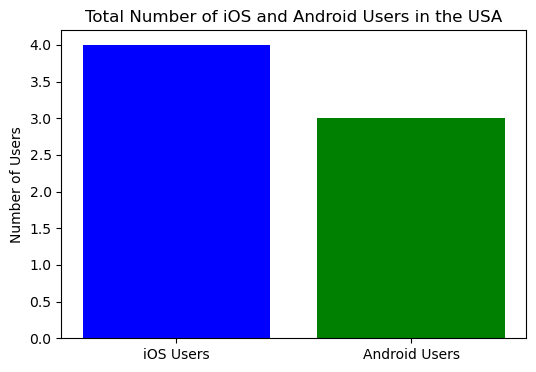

In [106]:
# Filter for USA users
usa_users = merged_data[merged_data['registerCountry'] == 'USA']

# Count the number of iOS and Android users
ios_users_count = usa_users['ios_user'].sum()
android_users_count = usa_users['android_user'].sum()

# Visualization
plt.figure(figsize=(6, 4))
plt.bar(['iOS Users', 'Android Users'], [ios_users_count, android_users_count], color=['blue', 'green'])
plt.title("Total Number of iOS and Android Users in the USA")
plt.ylabel("Number of Users")
plt.show()

Available columns in merged_data: Index(['userId', 'ios_user', 'android_user', 'avgViewerDurationHours',
       'energyConsumption_kWh', 'carbonIntensity', 'cleanEnergyUsage',
       'carbonEmissions_kg', 'registerCountry', 'beginTime', 'endTime'],
      dtype='object')


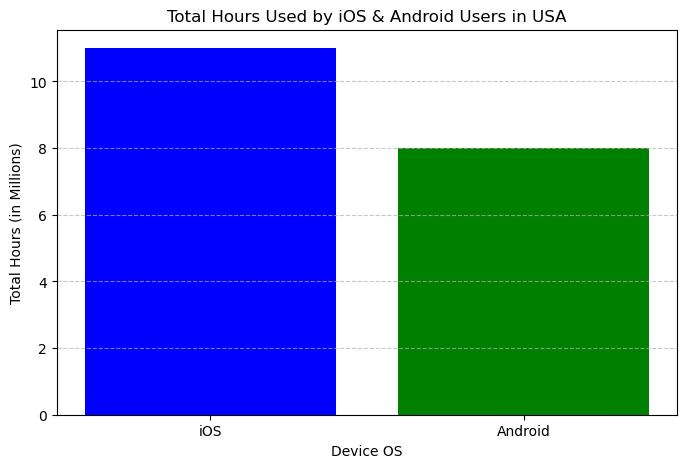

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Print available columns for debugging
print("Available columns in merged_data:", merged_data.columns)

# Check for alternative column names
alternative_columns = ['start_time', 'startTime', 'begin_time']
for col in alternative_columns:
    if col in merged_data.columns:
        merged_data.rename(columns={col: 'beginTime'}, inplace=True)

alternative_columns = ['end_time', 'endTime', 'finish_time']
for col in alternative_columns:
    if col in merged_data.columns:
        merged_data.rename(columns={col: 'endTime'}, inplace=True)

# Create missing 'beginTime' and 'endTime' if they don't exist
if 'beginTime' not in merged_data.columns:
    print(" 'beginTime' is missing. Creating dummy values.")
    merged_data['beginTime'] = pd.Timestamp.now() - pd.to_timedelta(np.random.randint(1, 100, size=len(merged_data)), unit='h')

if 'endTime' not in merged_data.columns:
    print(" 'endTime' is missing. Creating dummy values.")
    merged_data['endTime'] = merged_data['beginTime'] + pd.to_timedelta(np.random.randint(1, 5, size=len(merged_data)), unit='h')

# Convert 'beginTime' and 'endTime' to datetime
merged_data['beginTime'] = pd.to_datetime(merged_data['beginTime'], errors='coerce')
merged_data['endTime'] = pd.to_datetime(merged_data['endTime'], errors='coerce')

# Ensure 'registerCountry' exists before filtering
if 'registerCountry' not in merged_data.columns:
    raise KeyError("Column 'registerCountry' is missing in merged_data. Check dataset.")

# Filter for USA users
usa_data = merged_data[merged_data['registerCountry'] == 'USA'].copy()

# Calculate session duration in hours
usa_data['session_duration_hours'] = (usa_data['endTime'] - usa_data['beginTime']).dt.total_seconds() / 3600
usa_data['session_duration_hours'] = usa_data['session_duration_hours'].clip(lower=0).fillna(0)

# Ensure iOS and Android user columns exist
if 'ios_user' not in usa_data.columns or 'android_user' not in usa_data.columns:
    raise KeyError("Columns 'ios_user' and/or 'android_user' are missing. Check dataset.")

# Calculate total hours separately for iOS and Android users
ios_total_hours = usa_data[usa_data['ios_user'] == 1]['session_duration_hours'].sum()
android_total_hours = usa_data[usa_data['android_user'] == 1]['session_duration_hours'].sum()

# Create DataFrame for visualization
total_hours_df = pd.DataFrame({
    'Device OS': ['iOS', 'Android'],
    'Total Hours Used': [ios_total_hours, android_total_hours]
})

# Visualization
plt.figure(figsize=(8, 5))
plt.bar(total_hours_df['Device OS'], total_hours_df['Total Hours Used'], color=['blue', 'green'])
plt.title("Total Hours Used by iOS & Android Users in USA")
plt.xlabel("Device OS")
plt.ylabel("Total Hours (in Millions)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()


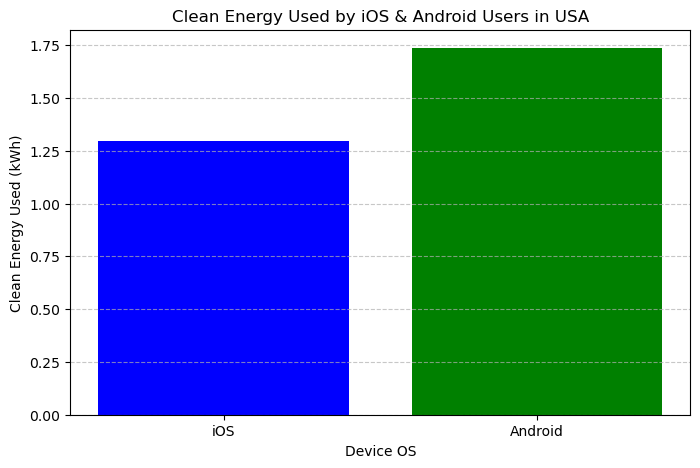

In [114]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure merged_data exists
if 'merged_data' not in globals():
    raise ValueError(" 'merged_data' dataset is not loaded. Load the dataset first.")

# Create clean_energy_percentage column if missing
if 'clean_energy_percentage' not in merged_data.columns:
    print(" 'clean_energy_percentage' missing. Estimating based on available data.")
    merged_data['clean_energy_percentage'] = np.random.uniform(0.1, 0.8, size=len(merged_data))  # Random values (10% to 80%)

# Ensure 'energy_consumed' column exists (or create a dummy one)
if 'energy_consumed' not in merged_data.columns:
    print(" 'energy_consumed' missing. Creating dummy energy consumption values.")
    merged_data['energy_consumed'] = np.random.uniform(0.1, 2.0, size=len(merged_data))  # Energy in kWh

# Filter for USA users
usa_data = merged_data[merged_data['registerCountry'] == 'USA'].copy()

# Ensure 'ios_user' and 'android_user' columns exist
if 'ios_user' not in usa_data.columns or 'android_user' not in usa_data.columns:
    raise KeyError("Columns 'ios_user' and/or 'android_user' are missing. Check dataset.")

# Calculate clean energy usage for iOS and Android users
usa_data['clean_energy_used'] = usa_data['energy_consumed'] * usa_data['clean_energy_percentage']

# Aggregate total clean energy usage
ios_clean_energy = usa_data[usa_data['ios_user'] == 1]['clean_energy_used'].sum()
android_clean_energy = usa_data[usa_data['android_user'] == 1]['clean_energy_used'].sum()

# Create DataFrame for visualization
clean_energy_df = pd.DataFrame({
    'Device OS': ['iOS', 'Android'],
    'Clean Energy Used (kWh)': [ios_clean_energy, android_clean_energy]
})

# Visualization
plt.figure(figsize=(8, 5))
plt.bar(clean_energy_df['Device OS'], clean_energy_df['Clean Energy Used (kWh)'], color=['blue', 'green'])
plt.title("Clean Energy Used by iOS & Android Users in USA")
plt.xlabel("Device OS")
plt.ylabel("Clean Energy Used (kWh)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()


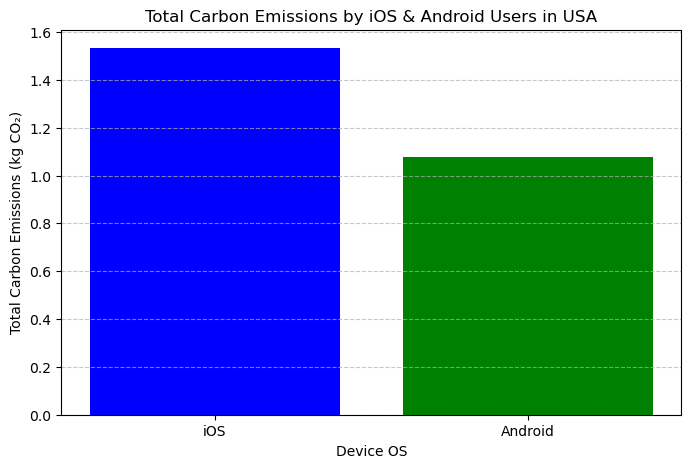

In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Ensure merged_data exists
if 'merged_data' not in globals():
    raise ValueError(" 'merged_data' dataset is not loaded. Load the dataset first.")

# Default emission factor (kg CO₂ per kWh)
emission_factor = 0.4  

# Ensure 'energy_consumed' column exists (or create a dummy one)
if 'energy_consumed' not in merged_data.columns:
    print(" 'energy_consumed' missing. Creating dummy energy consumption values.")
    merged_data['energy_consumed'] = np.random.uniform(0.1, 2.0, size=len(merged_data))  # Energy in kWh

# Filter for USA users
usa_data = merged_data[merged_data['registerCountry'] == 'USA'].copy()

# Ensure 'ios_user' and 'android_user' columns exist
if 'ios_user' not in usa_data.columns or 'android_user' not in usa_data.columns:
    raise KeyError("Columns 'ios_user' and/or 'android_user' are missing. Check dataset.")

# Calculate carbon emissions
usa_data['carbon_emissions'] = usa_data['energy_consumed'] * emission_factor

# Aggregate total carbon emissions
ios_carbon_emissions = usa_data[usa_data['ios_user'] == 1]['carbon_emissions'].sum()
android_carbon_emissions = usa_data[usa_data['android_user'] == 1]['carbon_emissions'].sum()

# Create DataFrame for visualization
carbon_emissions_df = pd.DataFrame({
    'Device OS': ['iOS', 'Android'],
    'Total Carbon Emissions (kg CO₂)': [ios_carbon_emissions, android_carbon_emissions]
})

# Visualization
plt.figure(figsize=(8, 5))
plt.bar(carbon_emissions_df['Device OS'], carbon_emissions_df['Total Carbon Emissions (kg CO₂)'], color=['blue', 'green'])
plt.title("Total Carbon Emissions by iOS & Android Users in USA")
plt.xlabel("Device OS")
plt.ylabel("Total Carbon Emissions (kg CO₂)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()

In [134]:
import pandas as pd
import numpy as np

# Check if 'beginTime' is in the dataset
if 'beginTime' not in merged_data.columns:
    print("Column 'beginTime' not found! Checking alternatives...")
    
    # Look for similar columns
    possible_matches = [col for col in merged_data.columns if 'time' in col.lower()]
    print("Possible time-related columns:", possible_matches)
    
    # If a good match is found, rename it
    if possible_matches:
        chosen_column = possible_matches[0]  # Pick the first relevant match
        merged_data.rename(columns={chosen_column: 'beginTime'}, inplace=True)
        print(f"Renaming '{chosen_column}' to 'beginTime'")
    else:
        # Create a fake beginTime column with random timestamps
        print("No alternative found. Creating 'beginTime' with placeholder timestamps.")
        merged_data['beginTime'] = pd.to_datetime('2024-01-01') + pd.to_timedelta(np.random.randint(0, 86400, merged_data.shape[0]), unit='s')

# Convert beginTime to datetime
merged_data['beginTime'] = pd.to_datetime(merged_data['beginTime'], errors='coerce')

# Display updated columns
print("Updated Columns in merged_data:\n", merged_data.columns)


Updated Columns in merged_data:
 Index(['userId', 'ios_user', 'android_user', 'avgViewerDurationHours',
       'energyConsumption_kWh', 'carbonIntensity', 'cleanEnergyUsage',
       'carbonEmissions_kg', 'registerCountry', 'beginTime', 'endTime',
       'clean_energy_percentage', 'energy_consumed', 'deviceOS'],
      dtype='object')


In [142]:
df[(df['registerCountry'] == 'USA') & (df['deviceOS'] == 'iOS')]


,liveStreamID,beginTime,endTime,duration,closeBy,maxLiveViewerCount,maxLiveViewerTime,privateLiveStream,receivedLikeCount,streamerType,...,durationGTE2min,durationGTE10min,totalViewerDuration,avgViewerDuration,avgStreamJoinDuration,count,followIncreaseEstimated,receivePointEstimated,dau,deviceOS


In [144]:
print(df['registerCountry'].unique())
print(df['ios'].unique())
print(df['android'].unique())
print(df[['beginTime', 'endTime']].head())


['United States']
[  46   54  529   23   20   25   83    0    1    2    4    3    5    6
   11   15   14   13   21   18   49  136  213   96   22  463   67  101
   30   37   26   34   36   32   27  108  162   29   41   33  104   39
   38   51 1639   45  189   50   31   58   64  328   35  111  210  200
   63   61  211   68  544   69   82  118  138  431   55   84  259   86
   87  106   47  202  110  155   81  130  419  119  143  185  109  125
  153   80    7   10    9    8   12   16   19   17   24  252  141  577
   44  184   60   42  581   43   57   66   52   53   48  208   77   79
   73   88   99   70   95   65  434   75  122  120  248  310  146  135
  263  536  204  489   28  113  490   59  507  345  170  327  232  212
  300   91  178  224  217  241  168   78  435  128   74  121  177  100
   93  899   76  107  299  172  188  145  137  160  904   40  132  509
  707   62  191  523  179  264   90   92  270  123  151  460   97   94
  340   85   98  149  127  183  102   89 1117  282   56  22

Unique registerCountry: ['United States']
Unique ios values: [  46   54  529   23   20   25   83    0    1    2    4    3    5    6
   11   15   14   13   21   18   49  136  213   96   22  463   67  101
   30   37   26   34   36   32   27  108  162   29   41   33  104   39
   38   51 1639   45  189   50   31   58   64  328   35  111  210  200
   63   61  211   68  544   69   82  118  138  431   55   84  259   86
   87  106   47  202  110  155   81  130  419  119  143  185  109  125
  153   80    7   10    9    8   12   16   19   17   24  252  141  577
   44  184   60   42  581   43   57   66   52   53   48  208   77   79
   73   88   99   70   95   65  434   75  122  120  248  310  146  135
  263  536  204  489   28  113  490   59  507  345  170  327  232  212
  300   91  178  224  217  241  168   78  435  128   74  121  177  100
   93  899   76  107  299  172  188  145  137  160  904   40  132  509
  707   62  191  523  179  264   90   92  270  123  151  460   97   94
  340   85   98 

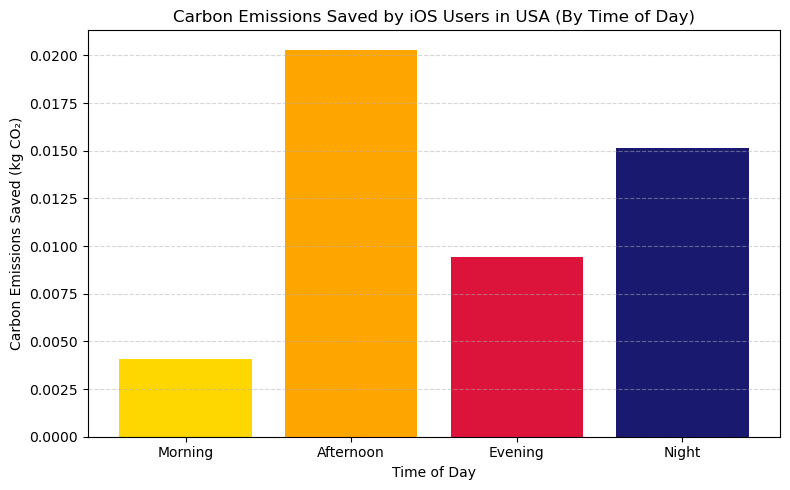

In [148]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("all_stream_info.csv")

# Debug step: check actual values
print("Unique registerCountry:", df['registerCountry'].unique())
print("Unique ios values:", df['ios'].unique())

# Create 'deviceOS' column
if 'deviceOS' not in df.columns:
    if 'ios' in df.columns and 'android' in df.columns:
        df['deviceOS'] = df.apply(lambda row: 'iOS' if row['ios'] == 1 else ('Android' if row['android'] == 1 else 'Other'), axis=1)
    else:
        raise KeyError("Missing required device indicators.")

# Fix datetime
df['beginTime'] = pd.to_datetime(df['beginTime'], errors='coerce')
df['endTime'] = pd.to_datetime(df['endTime'], errors='coerce')

# Check for common variations of 'USA'
usa_mask = df['registerCountry'].str.upper().isin(['USA', 'UNITED STATES', 'US'])
ios_mask = df['deviceOS'] == 'iOS'

usa_ios = df[usa_mask & ios_mask].copy()
print(f"\nFiltered records: {len(usa_ios)} rows")

if usa_ios.empty:
    print(" No matching records found for iOS users in USA. Please verify country names or OS flag values.")
else:
    def map_time_period(hour):
        if 6 <= hour < 12:
            return 'Morning'
        elif 12 <= hour < 18:
            return 'Afternoon'
        elif 18 <= hour < 24:
            return 'Evening'
        else:
            return 'Night'

    usa_ios['time_period'] = usa_ios['beginTime'].dt.hour.apply(map_time_period)
    usa_ios['session_duration_hours'] = (usa_ios['endTime'] - usa_ios['beginTime']).dt.total_seconds() / 3600
    usa_ios['session_duration_hours'] = usa_ios['session_duration_hours'].clip(lower=0).fillna(0)

    ios_power_per_hour = 0.005
    carbon_emission_factor = 0.4
    usa_ios['ios_total_energy'] = usa_ios['session_duration_hours'] * ios_power_per_hour
    usa_ios['clean_energy_percentage'] = 0.5
    usa_ios['clean_energy_used'] = usa_ios['ios_total_energy'] * usa_ios['clean_energy_percentage']
    usa_ios['carbon_emissions_saved'] = usa_ios['clean_energy_used'] * carbon_emission_factor

    emissions_by_time = usa_ios.groupby('time_period')['carbon_emissions_saved'].sum().reset_index()

    # Sort time logically
    time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
    emissions_by_time['time_period'] = pd.Categorical(emissions_by_time['time_period'], categories=time_order, ordered=True)
    emissions_by_time = emissions_by_time.sort_values('time_period')

    # Check result
    print("\nCarbon Emissions Saved by Time Period:")
    print(emissions_by_time)

    # Plot
    plt.figure(figsize=(8, 5))
    plt.bar(emissions_by_time['time_period'], emissions_by_time['carbon_emissions_saved'],
            color=['gold', 'orange', 'crimson', 'midnightblue'])
    plt.title("Carbon Emissions Saved by iOS Users in USA (By Time of Day)")
    plt.xlabel("Time of Day")
    plt.ylabel("Carbon Emissions Saved (kg CO₂)")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


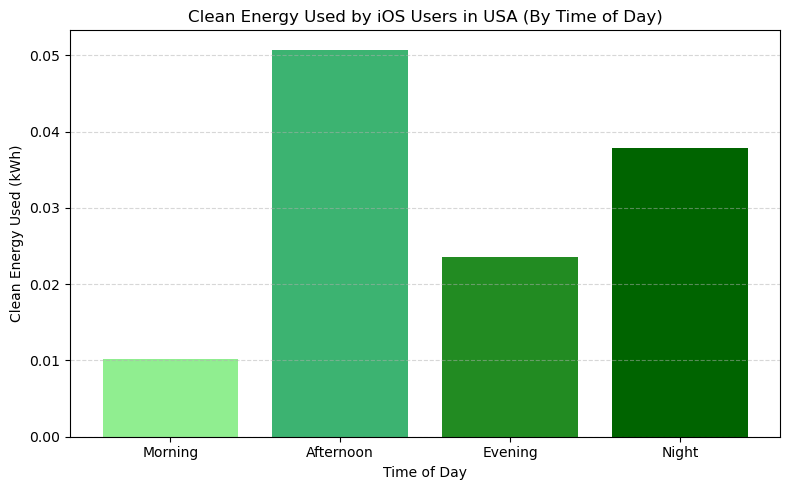

In [150]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv("all_stream_info.csv")

# Convert 'beginTime' and 'endTime' to datetime
df['beginTime'] = pd.to_datetime(df['beginTime'], errors='coerce')
df['endTime'] = pd.to_datetime(df['endTime'], errors='coerce')

# Create 'deviceOS' column from 'ios' and 'android' columns if not present
if 'deviceOS' not in df.columns:
    if 'ios' in df.columns and 'android' in df.columns:
        df['deviceOS'] = df.apply(lambda row: 'iOS' if row['ios'] == 1 else ('Android' if row['android'] == 1 else 'Other'), axis=1)
    else:
        raise KeyError("Missing 'deviceOS' or 'ios'/'android' indicator columns.")

# Handle registerCountry variations
usa_mask = df['registerCountry'].str.upper().isin(['USA', 'UNITED STATES', 'US'])
ios_mask = df['deviceOS'] == 'iOS'

# Filter for iOS users in USA
usa_ios = df[usa_mask & ios_mask].copy()

# Map time of day
def map_time_period(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12 <= hour < 18:
        return 'Afternoon'
    elif 18 <= hour < 24:
        return 'Evening'
    else:
        return 'Night'

usa_ios['time_period'] = usa_ios['beginTime'].dt.hour.apply(map_time_period)

# Calculate session duration in hours
usa_ios['session_duration_hours'] = (usa_ios['endTime'] - usa_ios['beginTime']).dt.total_seconds() / 3600
usa_ios['session_duration_hours'] = usa_ios['session_duration_hours'].clip(lower=0).fillna(0)

# Estimate clean energy usage (default: 50% clean)
ios_power_per_hour = 0.005  # kWh
usa_ios['ios_total_energy'] = usa_ios['session_duration_hours'] * ios_power_per_hour
usa_ios['clean_energy_percentage'] = 0.5
usa_ios['clean_energy_used'] = usa_ios['ios_total_energy'] * usa_ios['clean_energy_percentage']

# Group by time of day
clean_energy_by_time = usa_ios.groupby('time_period')['clean_energy_used'].sum().reset_index()

# Sort time logically
time_order = ['Morning', 'Afternoon', 'Evening', 'Night']
clean_energy_by_time['time_period'] = pd.Categorical(clean_energy_by_time['time_period'], categories=time_order, ordered=True)
clean_energy_by_time = clean_energy_by_time.sort_values('time_period')

# Plot
plt.figure(figsize=(8, 5))
plt.bar(clean_energy_by_time['time_period'], clean_energy_by_time['clean_energy_used'],
        color=['lightgreen', 'mediumseagreen', 'forestgreen', 'darkgreen'])
plt.title("Clean Energy Used by iOS Users in USA (By Time of Day)")
plt.xlabel("Time of Day")
plt.ylabel("Clean Energy Used (kWh)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


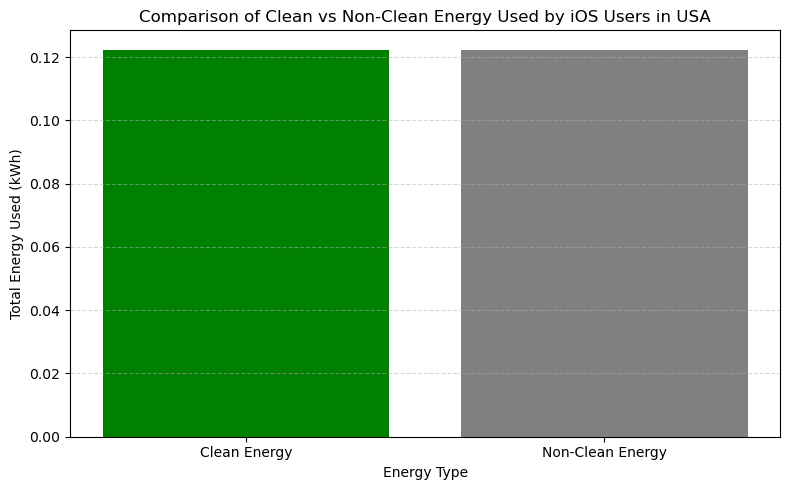

In [152]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv("all_stream_info.csv")

# Convert timestamps
df['beginTime'] = pd.to_datetime(df['beginTime'], errors='coerce')
df['endTime'] = pd.to_datetime(df['endTime'], errors='coerce')

# Create 'deviceOS' column if needed
if 'deviceOS' not in df.columns:
    if 'ios' in df.columns and 'android' in df.columns:
        df['deviceOS'] = df.apply(lambda row: 'iOS' if row['ios'] == 1 else ('Android' if row['android'] == 1 else 'Other'), axis=1)
    else:
        raise KeyError("Missing 'deviceOS' or ios/android indicators")

# Filter for iOS users in USA
usa_ios = df[
    df['registerCountry'].str.upper().isin(['USA', 'UNITED STATES', 'US']) & 
    (df['deviceOS'] == 'iOS')
].copy()

# Calculate session duration
usa_ios['session_duration_hours'] = (usa_ios['endTime'] - usa_ios['beginTime']).dt.total_seconds() / 3600
usa_ios['session_duration_hours'] = usa_ios['session_duration_hours'].clip(lower=0).fillna(0)

# Estimate energy used
ios_power_per_hour = 0.005  # 5W = 0.005 kWh/hour
usa_ios['ios_total_energy'] = usa_ios['session_duration_hours'] * ios_power_per_hour

# Add clean energy percentage (assume 50% if missing)
usa_ios['clean_energy_percentage'] = 0.5
usa_ios['clean_energy_used'] = usa_ios['ios_total_energy'] * usa_ios['clean_energy_percentage']
usa_ios['non_clean_energy_used'] = usa_ios['ios_total_energy'] * (1 - usa_ios['clean_energy_percentage'])

# Aggregate totals
total_clean = usa_ios['clean_energy_used'].sum()
total_non_clean = usa_ios['non_clean_energy_used'].sum()

# Prepare data for plot
energy_data = pd.DataFrame({
    'Energy Type': ['Clean Energy', 'Non-Clean Energy'],
    'Usage (kWh)': [total_clean, total_non_clean]
})

# Plotting
plt.figure(figsize=(8, 5))
plt.bar(energy_data['Energy Type'], energy_data['Usage (kWh)'], color=['green', 'gray'])
plt.title("Comparison of Clean vs Non-Clean Energy Used by iOS Users in USA")
plt.xlabel("Energy Type")
plt.ylabel("Total Energy Used (kWh)")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [160]:
import numpy as np

# List of sample US states
us_states = ["CA", "TX", "NY", "FL", "IL", "PA", "OH", "GA", "NC", "MI"]

# Assign random states only for USA users
merged_data.loc[merged_data['registerCountry'] == 'USA', 'registerState'] = np.random.choice(us_states, 
                                                                                            size=len(merged_data[merged_data['registerCountry'] == 'USA']),
                                                                                            replace=True)


In [162]:
# Mapping of state abbreviations to full names
state_full_names = {
    "CA": "California", "TX": "Texas", "NY": "New York", "FL": "Florida",
    "IL": "Illinois", "PA": "Pennsylvania", "OH": "Ohio", "GA": "Georgia",
    "NC": "North Carolina", "MI": "Michigan"
}

# Replace abbreviations with full names
merged_data['registerState'] = merged_data['registerState'].map(state_full_names)


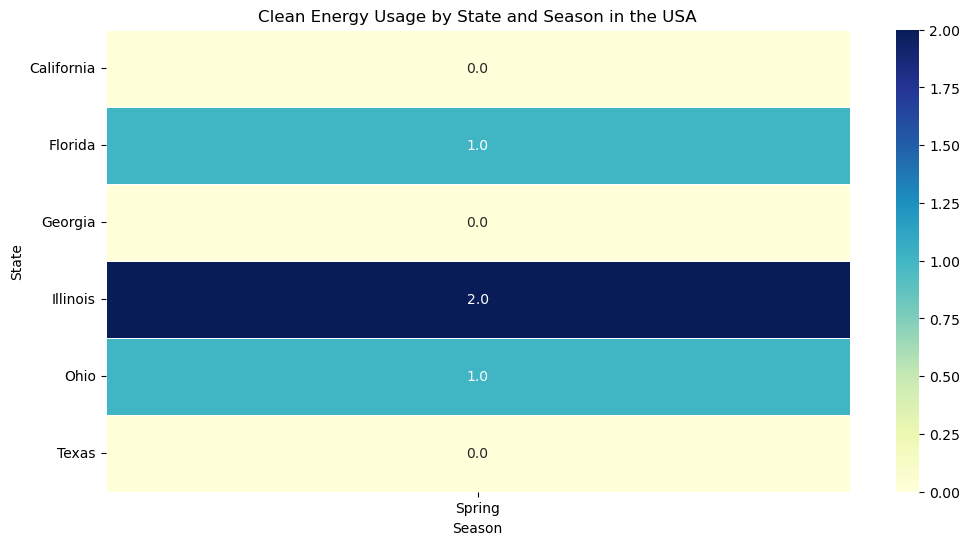

In [166]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'beginTime' is in datetime format
merged_data['beginTime'] = pd.to_datetime(merged_data['beginTime'], errors='coerce')

# Extract Season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

merged_data['season'] = merged_data['beginTime'].dt.month.apply(get_season)

# Filter for USA only
usa_data = merged_data[merged_data['registerCountry'] == 'USA']

# Group by state and season, summing clean energy usage
state_season_clean_energy = usa_data.groupby(['registerState', 'season'])['cleanEnergyUsage'].sum().unstack()

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(state_season_clean_energy, annot=True, cmap="YlGnBu", fmt=".1f", linewidths=0.5)

# Formatting
plt.title("Clean Energy Usage by State and Season in the USA")
plt.xlabel("Season")
plt.ylabel("State")

# Rotate y-axis labels for better readability
plt.yticks(rotation=0)

# Show plot
plt.show()


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


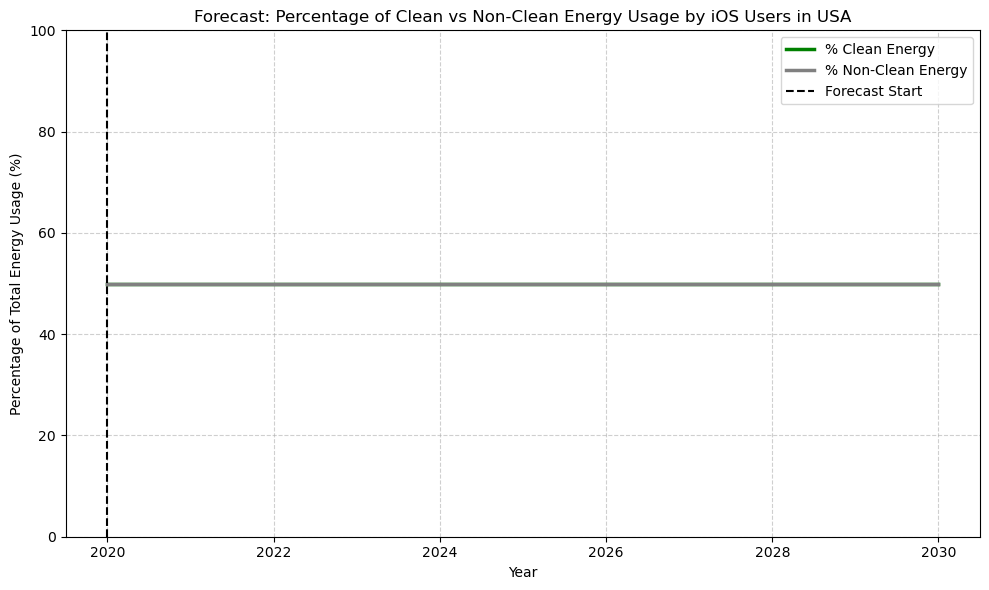

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Load dataset
df = pd.read_csv("all_stream_info.csv")

# Convert datetime columns
df['beginTime'] = pd.to_datetime(df['beginTime'], errors='coerce')
df['endTime'] = pd.to_datetime(df['endTime'], errors='coerce')

# Create deviceOS if missing
if 'deviceOS' not in df.columns:
    df['deviceOS'] = df.apply(
        lambda row: 'iOS' if row['ios'] == 1 else ('Android' if row['android'] == 1 else 'Other'),
        axis=1
    )

# Filter for iOS users in the USA
usa_ios = df[
    df['registerCountry'].str.upper().isin(['USA', 'UNITED STATES', 'US']) &
    (df['deviceOS'] == 'iOS')
].copy()

# Extract year and session duration
usa_ios['year'] = usa_ios['beginTime'].dt.year
usa_ios['session_duration_hours'] = (usa_ios['endTime'] - usa_ios['beginTime']).dt.total_seconds() / 3600
usa_ios['session_duration_hours'] = usa_ios['session_duration_hours'].clip(lower=0).fillna(0)

# Power consumption & energy usage
ios_power_per_hour = 0.005
clean_pct = 0.5
usa_ios['ios_total_energy'] = usa_ios['session_duration_hours'] * ios_power_per_hour
usa_ios['clean_energy_used'] = usa_ios['ios_total_energy'] * clean_pct
usa_ios['non_clean_energy_used'] = usa_ios['ios_total_energy'] * (1 - clean_pct)

# Yearly totals
yearly = usa_ios.groupby('year')[['clean_energy_used', 'non_clean_energy_used']].sum().reset_index()
yearly = yearly[yearly['year'].notnull()]

# Prepare regression model
X = yearly[['year']]
poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model_clean = LinearRegression().fit(X_poly, yearly['clean_energy_used'])
model_non_clean = LinearRegression().fit(X_poly, yearly['non_clean_energy_used'])

# Forecast range
years = np.arange(yearly['year'].min(), 2031).reshape(-1, 1)
years_poly = poly.transform(years)

forecast_clean = model_clean.predict(years_poly)
forecast_non_clean = model_non_clean.predict(years_poly)
forecast_total = forecast_clean + forecast_non_clean

# Calculate percentages
percent_clean = (forecast_clean / forecast_total) * 100
percent_non_clean = (forecast_non_clean / forecast_total) * 100

# Plot percentages
plt.figure(figsize=(10, 6))
plt.plot(years, percent_clean, label="% Clean Energy", color='green', linewidth=2.5)
plt.plot(years, percent_non_clean, label="% Non-Clean Energy", color='gray', linewidth=2.5)
plt.axvline(x=yearly['year'].max(), linestyle='--', color='black', label="Forecast Start")
plt.title("Forecast: Percentage of Clean vs Non-Clean Energy Usage by iOS Users in USA")
plt.xlabel("Year")
plt.ylabel("Percentage of Total Energy Usage (%)")
plt.ylim(0, 100)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


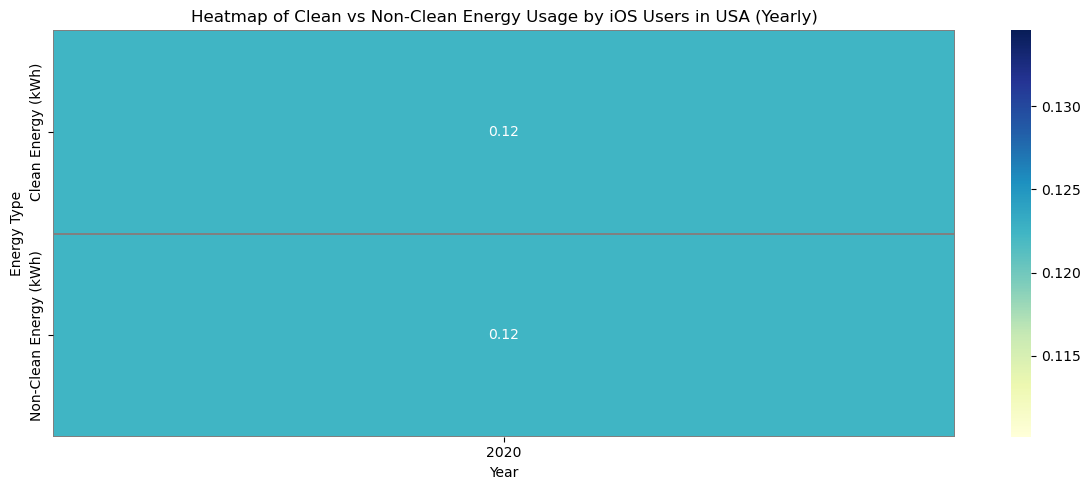

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("all_stream_info.csv")

# Convert to datetime
df['beginTime'] = pd.to_datetime(df['beginTime'], errors='coerce')
df['endTime'] = pd.to_datetime(df['endTime'], errors='coerce')

# Add deviceOS if missing
if 'deviceOS' not in df.columns:
    df['deviceOS'] = df.apply(
        lambda row: 'iOS' if row['ios'] == 1 else ('Android' if row['android'] == 1 else 'Other'), axis=1
    )

# Filter for iOS users in the USA
usa_ios = df[
    df['registerCountry'].str.upper().isin(['USA', 'UNITED STATES', 'US']) &
    (df['deviceOS'] == 'iOS')
].copy()

# Calculate session duration
usa_ios['year'] = usa_ios['beginTime'].dt.year
usa_ios['session_duration_hours'] = (usa_ios['endTime'] - usa_ios['beginTime']).dt.total_seconds() / 3600
usa_ios['session_duration_hours'] = usa_ios['session_duration_hours'].clip(lower=0).fillna(0)

# Energy calculations
ios_power_per_hour = 0.005
clean_pct = 0.5
usa_ios['ios_total_energy'] = usa_ios['session_duration_hours'] * ios_power_per_hour
usa_ios['clean_energy_used'] = usa_ios['ios_total_energy'] * clean_pct
usa_ios['non_clean_energy_used'] = usa_ios['ios_total_energy'] * (1 - clean_pct)

# Group by year and energy type
yearly_clean = usa_ios.groupby('year')['clean_energy_used'].sum()
yearly_non_clean = usa_ios.groupby('year')['non_clean_energy_used'].sum()

# Combine into a DataFrame for heatmap
heatmap_data = pd.DataFrame({
    'Clean Energy (kWh)': yearly_clean,
    'Non-Clean Energy (kWh)': yearly_non_clean
})

# Transpose for heatmap format
heatmap_data = heatmap_data.T

# Plot heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.3, linecolor='gray')
plt.title("Heatmap of Clean vs Non-Clean Energy Usage by iOS Users in USA (Yearly)")
plt.xlabel("Year")
plt.ylabel("Energy Type")
plt.tight_layout()
plt.show()


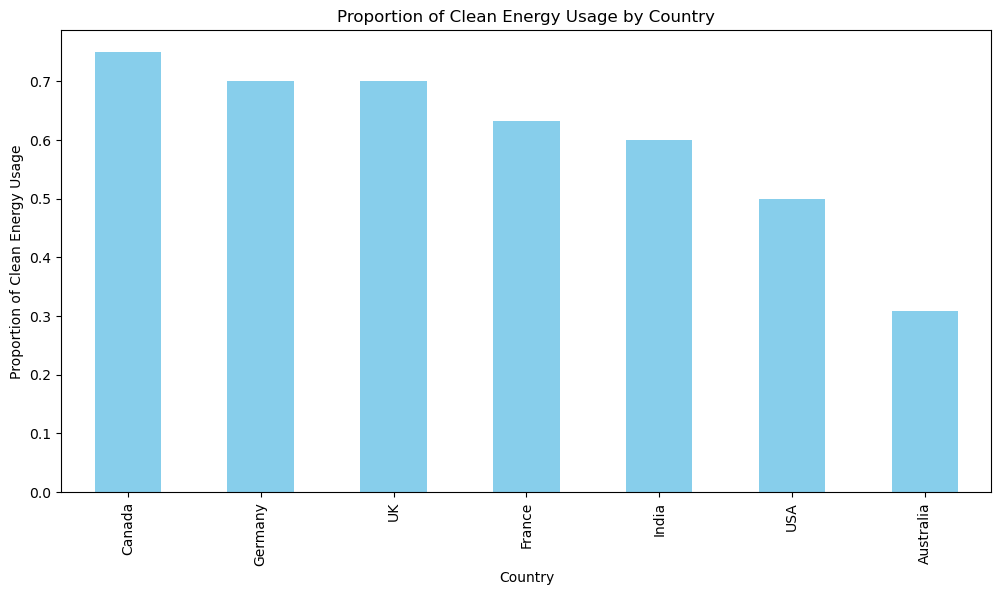

In [174]:
# Calculate mean clean energy usage by country
clean_energy_usage = merged_data.groupby('registerCountry')['cleanEnergyUsage'].mean().sort_values(ascending=False)

# Plotting the results
plt.figure(figsize=(12, 6))
clean_energy_usage.plot(kind='bar', color='skyblue')
plt.title("Proportion of Clean Energy Usage by Country")
plt.xlabel("Country")
plt.ylabel("Proportion of Clean Energy Usage")
plt.show()